In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load the predicted probabilities from a .npy file
gru_probs = np.load("dl_predictions/preds_gru_benchmarked.npy")
lstm_probs = np.load("dl_predictions/preds_lstm_benchmarked.npy")

gru_probs_worse = np.load("dl_predictions/preds_gru_worse.npy")
lstm_probs_worse = np.load("dl_predictions/preds_lstm_worse.npy")

gru_targs = np.load("dl_predictions/targs_gru_benchmarked.npy")
lstm_targs = np.load("dl_predictions/targs_3660670.npy")

lstm_probs.shape, gru_probs.shape, gru_probs_worse.shape, lstm_probs_worse.shape, gru_targs.shape

((1282848,), (1282848,), (1282848,), (1282848,), (1282848,))

In [3]:
unique, counts = np.unique(gru_targs, return_counts=True)
count_dict = dict(zip(unique.astype(int), counts))
print(f"Number of 0's: {count_dict.get(0)}")
print(f"Number of 1's: {count_dict.get(1)}")
print(f'Fraction of 1\'s: {count_dict.get(1) / (count_dict.get(0) + count_dict.get(1))}')

Number of 0's: 1268326
Number of 1's: 14522
Fraction of 1's: 0.011320125221382425


In [83]:
def compute_fraction_overlap(lstm_probs, gru_probs, thresh, targs):
    # 1) Find the top percentile thresholds
    lstm_threshold = np.percentile(lstm_probs, thresh)
    gru_threshold = np.percentile(gru_probs, thresh)

    # 2) Compute binary predictions
    lstm_pred = (lstm_probs >= lstm_threshold).astype(int)
    gru_pred = (gru_probs >= gru_threshold).astype(int)

    # 3) Fraction of GRU top thresh% (pred=1) who are also LSTM top thresh%
    gru_top_idx = np.where(gru_pred == 1)[0]
    gru_sepsis_fraction = np.sum(targs[gru_top_idx] == 1) / len(gru_top_idx)

    lstm_top_idx = np.where(lstm_pred == 1)[0]
    lstm_sepsis_fraction = np.sum(targs[lstm_top_idx] == 1) / len(lstm_top_idx)

    overlap_count = np.sum(lstm_pred[gru_top_idx] == 1)
    fraction_overlap = overlap_count / len(gru_top_idx) if len(gru_top_idx) > 0 else 0
    
    print(f"GRU top {thresh}% who get sepsis: {gru_sepsis_fraction:.4f},\nLSTM top {thresh}% who get sepsis: {lstm_sepsis_fraction:.4f},\noverlap: {fraction_overlap:.4f}\n")

compute_fraction_overlap(lstm_probs, gru_probs, 95, gru_targs)
compute_fraction_overlap(lstm_probs, gru_probs, 90, gru_targs)
compute_fraction_overlap(lstm_probs, gru_probs, 85, gru_targs)

GRU top 95% who get sepsis: 0.0624,
LSTM top 95% who get sepsis: 0.0565,
overlap: 0.5233

GRU top 90% who get sepsis: 0.0466,
LSTM top 90% who get sepsis: 0.0435,
overlap: 0.6003

GRU top 85% who get sepsis: 0.0389,
LSTM top 85% who get sepsis: 0.0363,
overlap: 0.6414



In [84]:
compute_fraction_overlap(lstm_probs_worse, gru_probs_worse, 95, gru_targs)
compute_fraction_overlap(lstm_probs_worse, gru_probs_worse, 90, gru_targs)
compute_fraction_overlap(lstm_probs_worse, gru_probs_worse, 85, gru_targs)

GRU top 95% who get sepsis: 0.0611,
LSTM top 95% who get sepsis: 0.0519,
overlap: 0.5044

GRU top 90% who get sepsis: 0.0462,
LSTM top 90% who get sepsis: 0.0411,
overlap: 0.5826

GRU top 85% who get sepsis: 0.0381,
LSTM top 85% who get sepsis: 0.0347,
overlap: 0.6278



In [ ]:
from sklearn.metrics import roc_auc_score

auc_gru = roc_auc_score(gru_targs, gru_probs)
auc_lstm = roc_auc_score(gru_targs, lstm_probs)
auc_gru_worse = roc_auc_score(gru_targs, gru_probs_worse)
auc_lstm_worse = roc_auc_score(gru_targs, lstm_probs_worse)

print(f"Baseline GRU AUC: {auc_gru:.4f}")
print(f"Baseline LSTM AUC: {auc_lstm:.4f}")
print(f"Worse GRU AUC: {auc_gru_worse:.4f}")
print(f"Worse LSTM AUC: {auc_lstm_worse:.4f}")

GRU AUC: 0.7636
LSTM AUC: 0.7382
GRU Worse AUC: 0.7611
LSTM Worse AUC: 0.7249


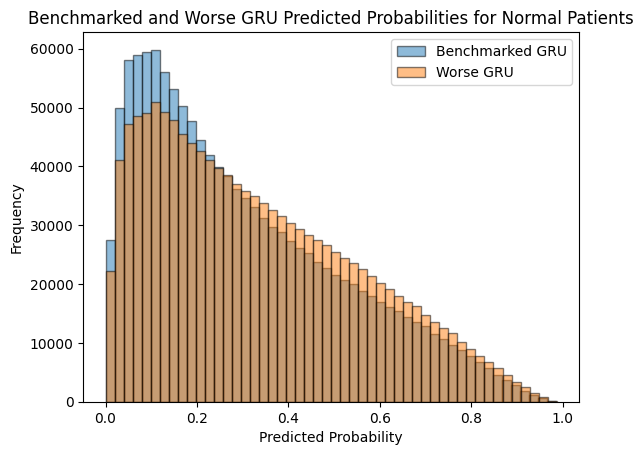

In [ ]:
# Separate probabilities by label
def probs_by_label(probs, targs):
    probs_0_idx = np.where(targs == 0)[0]
    probs_1_idx = np.where(targs == 1)[0]
    probs_0 = probs[probs_0_idx]
    probs_1 = probs[probs_1_idx]
    return probs_0, probs_1

gru_probs_0, gru_probs_1 = probs_by_label(gru_probs, gru_targs)
worse_gru_probs_0, worse_gru_probs_1 = probs_by_label(gru_probs_worse, gru_targs)

lstm_probs_0, lstm_probs_1 = probs_by_label(lstm_probs, lstm_targs)
worse_lstm_probs_0, worse_lstm_probs_1 = probs_by_label(lstm_probs_worse, lstm_targs)

plt.hist(gru_probs_0, bins=50, alpha=0.5, label='Benchmarked GRU', edgecolor='black')
plt.hist(worse_gru_probs_0, bins=50, alpha=0.5, label='Worse GRU', edgecolor='black')
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Benchmarked and Worse GRU Predicted Probabilities for Normal Patients")
plt.legend()
plt.show()

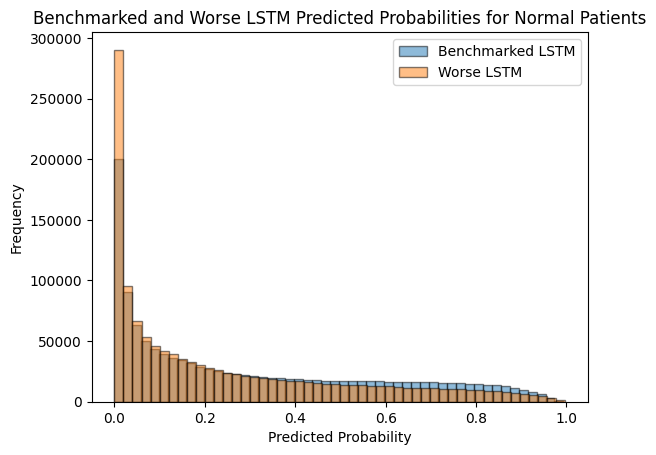

In [78]:
plt.hist(lstm_probs_0, bins=50, alpha=0.5, label='Benchmarked LSTM', edgecolor='black')
plt.hist(worse_lstm_probs_0, bins=50, alpha=0.5, label='Worse LSTM', edgecolor='black')
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Benchmarked and Worse LSTM Predicted Probabilities for Normal Patients")
plt.legend()
plt.show()

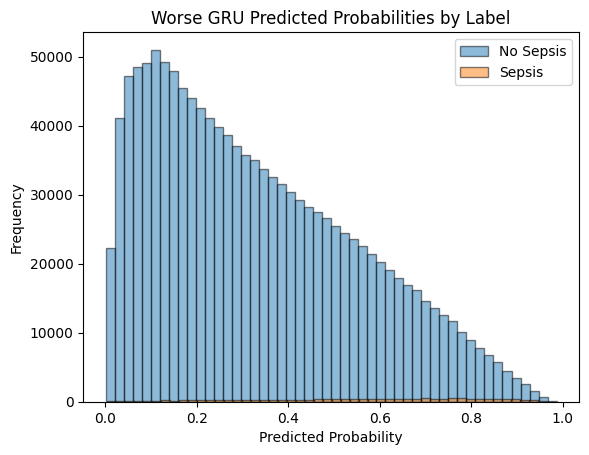

In [ ]:
plt.hist(worse_gru_probs_0, bins=50, alpha=0.5, label='No Sepsis', edgecolor='black')
plt.hist(worse_gru_probs_1, bins=50, alpha=0.5, label='Sepsis', edgecolor='black')
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Worse GRU Predicted Probabilities by Label")
plt.legend()
plt.show()

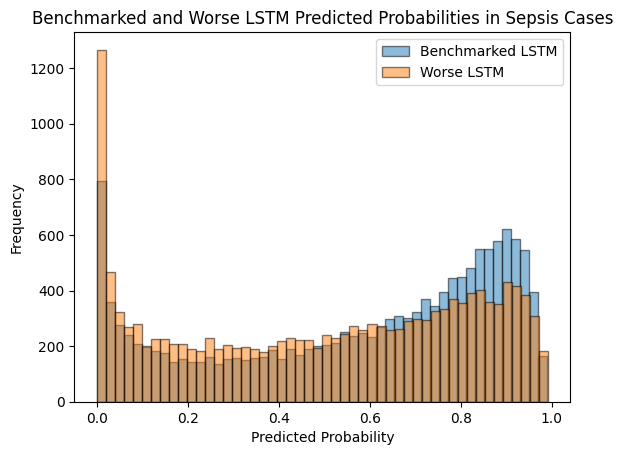

In [82]:
plt.hist(lstm_probs_1, bins=50, alpha=0.5, label='Benchmarked LSTM', edgecolor='black')
plt.hist(worse_lstm_probs_1, bins=50, alpha=0.5, label='Worse LSTM', edgecolor='black')
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Benchmarked and Worse LSTM Predicted Probabilities in Sepsis Cases")
plt.legend()
plt.show()

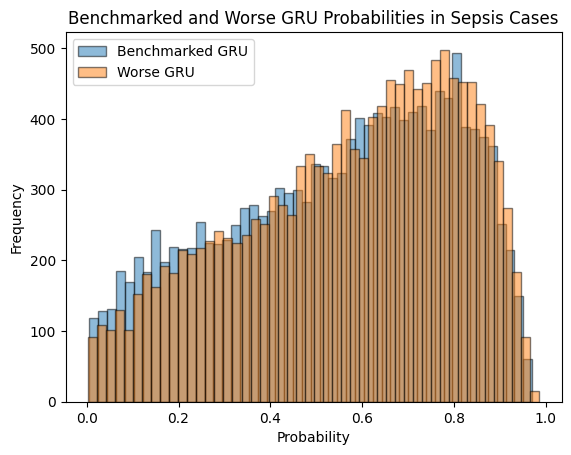

In [81]:
plt.hist(gru_probs_1, bins=50, alpha=0.5, label='Benchmarked GRU', edgecolor='black')
plt.hist(worse_gru_probs_1, bins=50, alpha=0.5, label='Worse GRU', edgecolor='black')
plt.title("Benchmarked and Worse GRU Probabilities in Sepsis Cases")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

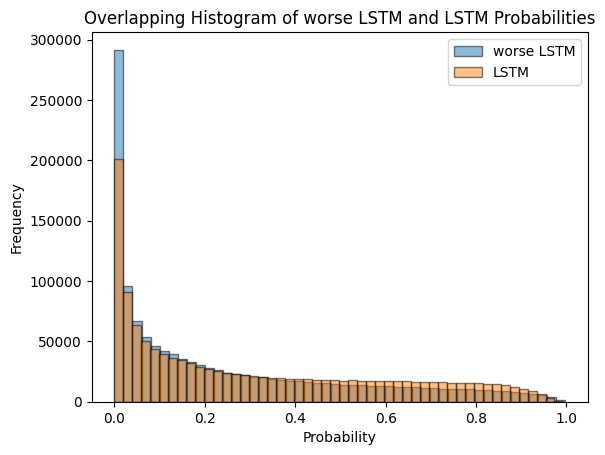

In [69]:
plt.hist(lstm_probs_worse, bins=50, alpha=0.5, label='worse LSTM', edgecolor='black')
plt.hist(lstm_probs, bins=50, alpha=0.5, label='LSTM', edgecolor='black')
plt.title("Overlapping Histogram of worse LSTM and LSTM Probabilities")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [1]:
import copy
import logging
import os

import gin
import json
import hashlib
import pandas as pd
import polars as pl
from pathlib import Path
import pickle
from timeit import default_timer as timer
from icu_benchmarks.constants import RunMode
from icu_benchmarks.run_utils import check_required_keys
from icu_benchmarks.data.constants import DataSplit as Split, DataSegment as Segment, VarType as Var

# Preprocess data
data_dir = Path("/Users/daphneyang/Yalalab/YAIB-cohorts/data/sepsis/eicu")

file_names = { # Found in config/tasks/common/PredictionTaskVariables.gin
    "DYNAMIC": "dyn.parquet",
    "OUTCOME": "outc.parquet",
    "STATIC": "sta.parquet",
}

data = {
        f: pl.read_parquet(data_dir / file_names[f]) for f in file_names.keys() if os.path.exists(data_dir / file_names[f])
    }

vars_gin_REQUIRED = { # Found in config/tasks/common/PredictionTaskVariables.gin
    "GROUP": "stay_id",
    "SEQUENCE": "time",
    "LABEL": "label",
    "DYNAMIC": ["alb", "alp", "alt", "ast", "be", "bicar", "bili", "bili_dir", "bnd", "bun", "ca", "cai", "ck", "ckmb", "cl",
        "crea", "crp", "dbp", "fgn", "fio2", "glu", "hgb", "hr", "inr_pt", "k", "lact", "lymph", "map", "mch", "mchc", "mcv",
        "methb", "mg", "na", "neut", "o2sat", "pco2", "ph", "phos", "plt", "po2", "ptt", "resp", "sbp", "temp", "tnt", "urine",
        "wbc"],
    "STATIC": ["age", "sex", "height", "weight"],
}

def check_sanitize_data(data, vars):
    """Check for duplicates in the loaded data and remove them."""
    group = vars[Var.group] if Var.group in vars.keys() else None
    sequence = vars[Var.sequence] if Var.sequence in vars.keys() else None
    keep = "last"
    if Segment.static in data.keys():
        old_len = len(data[Segment.static])
        data[Segment.static] = data[Segment.static].unique(subset=group, keep=keep, maintain_order=True)
        if old_len != len(data[Segment.static]):
            print(f"Warning: Removed {old_len - len(data[Segment.static])} duplicates from static data.")
    if Segment.dynamic in data.keys():
        old_len = len(data[Segment.dynamic])
        data[Segment.dynamic] = data[Segment.dynamic].unique(subset=[group, sequence], keep=keep, maintain_order=True)
        if old_len != len(data[Segment.dynamic]):
            print(f"Warning: Removed {old_len - len(data[Segment.dynamic])} duplicates from dynamic data.")
    if Segment.outcome in data.keys():
        old_len = len(data[Segment.outcome])
        if sequence in data[Segment.outcome].columns:
            # We have a dynamic outcome with group and sequence
            data[Segment.outcome] = data[Segment.outcome].unique(subset=[group, sequence], keep=keep, maintain_order=True)
        else:
            data[Segment.outcome] = data[Segment.outcome].unique(subset=[group], keep=keep, maintain_order=True)
        if old_len != len(data[Segment.outcome]):
            print(f"Warning: Removed {old_len - len(data[Segment.outcome])} duplicates from outcome data.")
    return data


data_original = check_sanitize_data(data, vars_gin_REQUIRED)  # No duplicates removed

data_original

{'DYNAMIC': shape: (6_417_043, 50)
 ┌─────────┬──────────────┬──────┬──────┬───┬───────────┬──────┬───────┬──────┐
 │ stay_id ┆ time         ┆ alb  ┆ alp  ┆ … ┆ temp      ┆ tnt  ┆ urine ┆ wbc  │
 │ ---     ┆ ---          ┆ ---  ┆ ---  ┆   ┆ ---       ┆ ---  ┆ ---   ┆ ---  │
 │ i32     ┆ duration[ms] ┆ f64  ┆ f64  ┆   ┆ f64       ┆ f64  ┆ f64   ┆ f64  │
 ╞═════════╪══════════════╪══════╪══════╪═══╪═══════════╪══════╪═══════╪══════╡
 │ 141179  ┆ 0ms          ┆ null ┆ null ┆ … ┆ null      ┆ null ┆ null  ┆ null │
 │ 141179  ┆ 1h           ┆ null ┆ null ┆ … ┆ null      ┆ null ┆ null  ┆ null │
 │ 141179  ┆ 2h           ┆ null ┆ null ┆ … ┆ 36.605556 ┆ null ┆ null  ┆ null │
 │ 141179  ┆ 3h           ┆ null ┆ null ┆ … ┆ null      ┆ null ┆ null  ┆ null │
 │ 141179  ┆ 4h           ┆ null ┆ null ┆ … ┆ null      ┆ null ┆ null  ┆ null │
 │ …       ┆ …            ┆ …    ┆ …    ┆ … ┆ …         ┆ …    ┆ …     ┆ …    │
 │ 3353263 ┆ 11h          ┆ null ┆ null ┆ … ┆ null      ┆ null ┆ null  ┆ null │
 │ 33

In [42]:
data_original['OUTCOME']['stay_id'].value_counts()

stay_id,count
i32,u32
626092,27
2271659,39
2619891,17
205392,16
1511388,169
…,…
456201,125
923774,18
579068,63


In [2]:
from sklearn.model_selection import train_test_split
import numpy as np

def make_single_split(
    data: dict[pd.DataFrame],
    vars: dict[str],
    train_size: float = 0.7,
    val_size: float = 0.15,
    test_size: float = 0.15,
    seed: int = 42,
    debug: bool = False,
    runmode: RunMode = RunMode.classification,
    polars: bool = True,
) -> dict[dict[pl.DataFrame]]:
    """Randomly split the data into training, validation, and test set (no cross-validation).

    Args:
        data: dictionary containing data divided into OUTCOME, STATIC, and DYNAMIC.
        vars: Contains the names of columns in the data.
        train_size: Proportion of data to use for training.
        val_size: Proportion of data to use for validation.
        test_size: Proportion of data to use for testing.
        seed: Random seed.
        debug: Load less data if true.

    Returns:
        Input data divided into 'train', 'val', and 'test'.
    """
    id = vars[Var.group]

    if debug:
        if polars:
            data[Segment.outcome] = data[Segment.outcome].sample(fraction=0.01, seed=seed)
        else:
            data[Segment.outcome] = data[Segment.outcome].sample(frac=0.01, random_state=seed)

    # Get unique IDs
    if polars:
        stays = pl.Series(name=id, values=data[Segment.outcome][id].unique()).to_numpy()
    else:
        stays = pd.Series(data[Segment.outcome][id].unique(), name=id)

    # Get labels for stratification if classification
    stratify_labels = None
    if Var.label in vars and runmode is RunMode.classification:
        if polars:
            stratify_labels = data[Segment.outcome].group_by(id).max()[vars[Var.label]].to_numpy()
        else:
            stratify_labels = data[Segment.outcome].groupby(id).max()[vars[Var.label]].reset_index(drop=True).to_numpy()

    # First split into train and temp (val+test)
    stays_train, stays_temp, = train_test_split(
        stays,
        train_size=train_size,
        random_state=seed,
        stratify=stratify_labels if stratify_labels is not None else None,
    )
    # Then split temp into val and test
    val_prop = val_size / (val_size + test_size)
    if polars:
        # Convert to numpy for isin
        stays_temp_np = stays_temp.to_numpy() if hasattr(stays_temp, "to_numpy") else np.array(stays_temp)
        stays_np = stays.to_numpy() if hasattr(stays, "to_numpy") else np.array(stays)
        mask = np.isin(stays_np, stays_temp_np)
        stratify_val = stratify_labels[mask] if stratify_labels is not None else None
        stays_val, stays_test = train_test_split(
            stays_temp,
            train_size=val_prop,
            random_state=seed,
            stratify=stratify_val,
        )
    else:
        stays_val, stays_test = train_test_split(
            stays_temp,
            train_size=val_prop,
            random_state=seed,
            stratify=stratify_labels[stays.isin(stays_temp)] if stratify_labels is not None else None,
        )

    # Convert to DataFrames for joining
    if polars:
        split = {
            Split.train: pl.DataFrame({id: stays_train}),
            Split.val: pl.DataFrame({id: stays_val}),
            Split.test: pl.DataFrame({id: stays_test}),
        }
    else:
        split = {
            Split.train: pd.DataFrame({id: stays_train}),
            Split.val: pd.DataFrame({id: stays_val}),
            Split.test: pd.DataFrame({id: stays_test}),
        }

    data_split = {}
    for fold in split.keys():
        if polars:
            data_split[fold] = {}
            for data_type in data.keys():
                # Ensure both join keys are Int64
                left = split[fold].with_columns(pl.col(id).cast(pl.Int64))
                right = data[data_type].with_columns(pl.col(id).cast(pl.Int64))
                data_split[fold][data_type] = (
                    left.join(right, on=id, how="left").sort(by=id)
                )
        else:
            data_split[fold] = {
                data_type: data[data_type].merge(split[fold], on=id, how="right", sort=True) for data_type in data.keys()
            }
    return data_split

data_train_val_test = make_single_split(
            data_original,
            vars_gin_REQUIRED
        )

In [3]:
from icu_benchmarks.data.preprocessor import Preprocessor, PolarsClassificationPreprocessor

modality_mapping = {
    "DYNAMIC": ["alb", "alp", "alt", "ast", "be", "bicar", "bili", "bili_dir", "bnd", "bun", "ca", "cai", "ck", "ckmb", "cl",
        "crea", "crp", "dbp", "fgn", "fio2", "glu", "hgb", "hr", "inr_pt", "k", "lact", "lymph", "map", "mch", "mchc", "mcv",
        "methb", "mg", "na", "neut", "o2sat", "pco2", "ph", "phos", "plt", "po2", "ptt", "resp", "sbp", "temp", "tnt", "urine",
        "wbc"],
    "STATIC": ["age", "sex", "height", "weight"],
}

vars_to_exclude = (
    modality_mapping.get("cat_clinical_notes") + modality_mapping.get("cat_med_embeddings_map")
    if (
        modality_mapping.get("cat_clinical_notes") is not None
        and modality_mapping.get("cat_med_embeddings_map") is not None
    )
    else None
)

preprocessor = PolarsClassificationPreprocessor(
        use_static_features=True,
        save_cache=data_dir / "preproc" / ("cache_LR" + "_recipe"),
        vars_to_exclude=vars_to_exclude,
    )
# if isinstance(preprocessor, PandasClassificationPreprocessor):
#     preprocessor.set_imputation_model(pretrained_imputation_model)


data_preprocessed = preprocessor.apply(data_train_val_test, vars_gin_REQUIRED)

for dict in data_preprocessed.values():
    for key, val in dict.items():
        # print(f"Data type: {key}")
        # print("Is NaN:")
        sel = dict[key].select(pl.selectors.numeric().is_nan().max())
        # print(sel.select(col.name for col in sel if col.item(0)))
        # logging.info(dict[key].select(pl.all().has_nulls()).sum_horizontal())
        # print("Has nulls:")
        sel = dict[key].select(pl.all().has_nulls())
        # print(sel.select(col.name for col in sel if col.item(0)))
        # dict[key] = val[:, [not (s.null_count() > 0) for s in val]]
        dict[key] = val.fill_null(strategy="zero")
        dict[key] = val.fill_nan(0)
        # print("Dropping columns with nulls")
        sel = dict[key].select(pl.all().has_nulls())
        # print(sel.select(col.name for col in sel if col.item(0)))

In [5]:
data_preprocessed

{'train': {'OUTCOME': shape: (4_485_373, 3)
  ┌─────────┬──────────────┬───────┐
  │ stay_id ┆ time         ┆ label │
  │ ---     ┆ ---          ┆ ---   │
  │ i64     ┆ duration[ms] ┆ bool  │
  ╞═════════╪══════════════╪═══════╡
  │ 141179  ┆ 0ms          ┆ false │
  │ 141179  ┆ 1h           ┆ false │
  │ 141179  ┆ 2h           ┆ false │
  │ 141179  ┆ 3h           ┆ false │
  │ 141179  ┆ 4h           ┆ false │
  │ …       ┆ …            ┆ …     │
  │ 3353263 ┆ 11h          ┆ false │
  │ 3353263 ┆ 12h          ┆ false │
  │ 3353263 ┆ 13h          ┆ false │
  │ 3353263 ┆ 14h          ┆ false │
  │ 3353263 ┆ 15h          ┆ false │
  └─────────┴──────────────┴───────┘,
  'FEATURES': shape: (4_485_373, 106)
  ┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
  │ stay_id ┆ time       ┆ alb       ┆ alp       ┆ … ┆ MissingIn ┆ MissingIn ┆ MissingIn ┆ MissingIn │
  │ ---     ┆ ---        ┆ ---       ┆ ---       ┆   ┆ dicator_a ┆ dicator_s ┆ dic

In [10]:
# Count the number of false and true labels in the Polars table X_train_outcome
label_counts = data_preprocessed["train"]["OUTCOME"]['label'].value_counts()
print(label_counts)

sample_counts = (data_preprocessed['train']['OUTCOME']["stay_id"].value_counts().shape[0], data_preprocessed['val']['OUTCOME']["stay_id"].value_counts().shape[0])
print(sample_counts)

shape: (2, 2)
┌───────┬─────────┐
│ label ┆ count   │
│ ---   ┆ ---     │
│ bool  ┆ u32     │
╞═══════╪═════════╡
│ false ┆ 4456557 │
│ true  ┆ 50940   │
└───────┴─────────┘
(86389, 18512)


In [ ]:
from icu_benchmarks.models.train import train_common
import os
import gin
import numpy as np
import torch
import logging
import polars as pl
from joblib import load
from torch.optim import Adam
from torch.utils.data import DataLoader
from pytorch_lightning.loggers import TensorBoardLogger, WandbLogger
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, TQDMProgressBar, LearningRateMonitor
from pathlib import Path
from icu_benchmarks.data.loader import PredictionPandasDataset, ImputationPandasDataset, PredictionPolarsDataset
from icu_benchmarks.models.utils import save_config_file, JSONMetricsLogger
from icu_benchmarks.constants import RunMode
from icu_benchmarks.data.constants import DataSplit as Split

from sklearn.linear_model import LogisticRegression

gin.parse_config_files_and_bindings(gin_config_files, args.hyperparams, finalize_config=False)
gin_config_files = (
            [Path(f"configs/experiments/{args.experiment}.gin")]
            if args.experiment
            else [model_path, Path(f"configs/tasks/{task}.gin")]  # A path for the model and a path for the task.
        )
log_dir = Path("/Users/daphneyang/YalaLab/yaib-logs/eicu/rep_0/fold_0")

loss = train_common(
                data_preprocessed,
                log_dir=log_dir,
                eval_only=False,
                load_weights=False,
                source_dir=None,
                reproducible=True,
                test_on='test',
                mode=RunMode.classification,
                cpu=True,
                verbose=False,
                use_wandb=False,
                train_only=False,
            )

ERROR:root:Path not found: config/prediction_models/common/MLCommon.gin


OSError: Unable to open file: config/prediction_models/common/MLCommon.gin. Searched config paths: [''].

In [ ]:
from icu_benchmarks.models.train import train_common
import os
import gin
import numpy as np
import torch
import logging
import polars as pl
from joblib import load
from torch.optim import Adam
from torch.utils.data import DataLoader
from pytorch_lightning.loggers import TensorBoardLogger, WandbLogger
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, TQDMProgressBar, LearningRateMonitor
from pathlib import Path
from icu_benchmarks.data.loader import PredictionPandasDataset, ImputationPandasDataset, PredictionPolarsDataset
from icu_benchmarks.models.utils import save_config_file, JSONMetricsLogger
from icu_benchmarks.constants import RunMode
from icu_benchmarks.data.constants import DataSplit as Split

from sklearn.linear_model import LogisticRegression

gin.parse_config_files_and_bindings(['config/prediction_models/common/MLCommon.gin', 'config/prediction_models/LogisticRegression.gin'], [])
log_dir = Path("/Users/daphneyang/Yalalab/yaib-logs/eicu/rep_0/fold_0")
mode = RunMode.classification
dataset_class = PredictionPolarsDataset
cpu_core_count = len(os.sched_getaffinity(0)) if hasattr(os, "sched_getaffinity") else os.cpu_count()
num_workers = min(cpu_core_count, torch.cuda.device_count() * 8 * int(torch.cuda.is_available()), 32)
epochs = 100
min_delta=1e-5
patience = 10
verbose = False
precision = 32
cpu = True
reproducible = True
test_on= Split.test

def assure_minimum_length(dataset):
    if len(dataset) < 2:
        return [dataset[0], dataset[0]]
    return dataset

train_dataset = dataset_class(data_preprocessed, split=Split.train, ram_cache=False, name="train", vars=vars_gin_REQUIRED)
val_dataset = dataset_class(data_preprocessed, split=Split.val, ram_cache=False, name="val", vars=vars_gin_REQUIRED)
train_dataset, val_dataset = assure_minimum_length(train_dataset), assure_minimum_length(val_dataset)
batch_size = min(1, len(train_dataset), len(val_dataset))

print(
        f"Training on {train_dataset.name} with {len(train_dataset)} samples and validating on {val_dataset.name} with"
        f" {len(val_dataset)} samples."
    )
print(f"Using {num_workers} workers for data loading.")

train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        drop_last=True,
        persistent_workers=False,
    )
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    drop_last=True,
    persistent_workers=False,
)

data_shape = next(iter(train_loader))[0].shape

model = LogisticRegression(max_iter=1000)

# model.set_weight(train_dataset, weight=None)
# model.set_trained_columns(train_dataset.get_feature_names())

loggers = [TensorBoardLogger(log_dir), JSONMetricsLogger(log_dir)]
callbacks = [
        EarlyStopping(monitor="val/loss", min_delta=min_delta, patience=patience, strict=False, verbose=verbose),
        ModelCheckpoint(log_dir, filename="model", save_top_k=1, save_last=True),
        LearningRateMonitor(logging_interval="step"),
    ]

trainer = Trainer(
        max_epochs=1,
        min_epochs=1,  # We need at least one epoch to get results.
        callbacks=callbacks,
        precision=precision,
        accelerator="auto" if not cpu else "cpu",
        devices=max(torch.cuda.device_count(), 1),
        deterministic="warn" if reproducible else False,
        benchmark=not reproducible,
        enable_progress_bar=verbose,
        logger=loggers,
        num_sanity_val_steps=2,  # Helps catch errors in the validation loop before training begins.
        log_every_n_steps=5,
    )

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

test_dataset = dataset_class(data_preprocessed, split=test_on, name="test", ram_cache=False, vars=vars_gin_REQUIRED)
test_dataset = assure_minimum_length(test_dataset)
print(f"Testing on {test_dataset.name}  with {len(test_dataset)} samples.")
test_loader = (
    # DataLoader(
    #     test_dataset,
    #     batch_size=min(batch_size * 4, len(test_dataset)),
    #     shuffle=False,
    #     num_workers=num_workers,
    #     pin_memory=True,
    #     drop_last=True,
    # )
    # if model.requires_backprop
    # else 
    DataLoader([test_dataset.to_tensor()], batch_size=1)
)


loss = train_common(
                data_preprocessed,
                log_dir=log_dir,
                eval_only=False,
                load_weights=False,
                source_dir=None,
                reproducible=True,
                test_on='test',
                mode=RunMode.classification,
                cpu=True,
                verbose=False,
                use_wandb=False,
                train_only=False,
            )

Training on train with 86389 samples and validating on val with 18512 samples.
Using 0 workers for data loading.


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/daphneyang/miniconda3/envs/yaib/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


TypeError: `model` must be a `LightningModule` or `torch._dynamo.OptimizedModule`, got `LogisticRegression`

In [22]:
torch.cuda.device_count() * 8 * int(torch.cuda.is_available())

0

In [4]:
# del data_train_val_test, data_original, data

def align_features_labels(features, outcome, keys=["stay_id", "time"], label_col="label"):
    # Ensure both are polars DataFrames
    features = features.with_columns([pl.col(k).cast(pl.Int64) for k in keys])
    outcome = outcome.with_columns([pl.col(k).cast(pl.Int64) for k in keys])
    # Join on both keys
    df = features.join(outcome.select(keys + [label_col]), on=keys, how="inner")
    X = df.drop(label_col)
    y = df[label_col]
    # Convert boolean to int if needed
    if y.dtype == pl.Boolean:
        y = y.cast(pl.Int8)
    return X[:, 1:].to_pandas().copy(deep=True), y.to_pandas().copy(deep=True)

def one_hot_encode_booleans(df):
    bool_cols = df.select_dtypes(include=['bool']).columns
    if len(bool_cols) > 0:
        df[bool_cols] = df[bool_cols].astype(int)
    return df

# Prepare data
X_train, y_train = align_features_labels(
    data_preprocessed['train']['FEATURES'], data_preprocessed['train']['OUTCOME'], keys=["stay_id", "time"], label_col="label"
)
X_val, y_val = align_features_labels(
    data_preprocessed['val']['FEATURES'], data_preprocessed['val']['OUTCOME'], keys=["stay_id", "time"], label_col="label"
)
X_test, y_test = align_features_labels(
    data_preprocessed['test']['FEATURES'], data_preprocessed['test']['OUTCOME'], keys=["stay_id", "time"], label_col="label"
)

X_train = one_hot_encode_booleans(X_train)
X_val = one_hot_encode_booleans(X_val)
X_test = one_hot_encode_booleans(X_test)

In [13]:
from joblib import load
from sklearn.metrics import roc_auc_score

# Load pretrained Logistic Regression model
lr_model = load("YAIB-models/sepsis/eicu/eicu_sepsis_LogisticRegression_repetition_0_fold_0_model.joblib")
lr_model.fit(X_train, y_train)

val_probs_lr = lr_model.predict_proba(X_val)[:, 1]
test_probs_lr = lr_model.predict_proba(X_test)[:, 1]

val_auc_lr = roc_auc_score(y_val, val_probs_lr)
test_auc_lr = roc_auc_score(y_test, test_probs_lr)

print(f"Logistic Regression - Validation AUC: {val_auc_lr:.4f}, Test AUC: {test_auc_lr:.4f}")

/Users/daphneyang/miniconda3/envs/yaib/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.1.3 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/daphneyang/miniconda3/envs/yaib/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import roc_auc_score
import torch

# Load pretrained GRU model (PyTorch)
class GRUClassifier(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=1):
        super().__init__()
        self.gru = torch.nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = torch.nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

# Example: adjust input_dim, hidden_dim, output_dim as needed
input_dim = X_train.shape[1]
hidden_dim = 64
output_dim = 1

gru_model = GRUClassifier(input_dim, hidden_dim, output_dim)
gru_model.load_state_dict(torch.load("pretrained_gru_model.torch", map_location="cpu"))
gru_model.eval()

# Prepare data for GRU: reshape to (batch, seq_len, features)
# Here, treat each sample as a sequence of length 1
def to_tensor(df):
    return torch.tensor(df.values, dtype=torch.float32).unsqueeze(1)

X_train_tensor = to_tensor(X_train)
X_val_tensor = to_tensor(X_val)
X_test_tensor = to_tensor(X_test)

with torch.no_grad():
    val_logits = gru_model(X_val_tensor).squeeze().numpy()
    test_logits = gru_model(X_test_tensor).squeeze().numpy()

val_auc_gru = roc_auc_score(y_val, val_logits)
test_auc_gru = roc_auc_score(y_test, test_logits)

print(f"GRU - Validation AUC: {val_auc_gru:.4f}, Test AUC: {test_auc_gru:.4f}")

In [6]:
del data, data_original, data_train_val_test

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Validation predictions and AUC
val_probs = lr_model.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, val_probs)
print(f"Validation AUC: {val_auc:.4f}")

# Test predictions and AUC
test_probs = lr_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_probs)
print(f"Test AUC: {test_auc:.4f}")

# Test probabilities
test_probs = lr_model.predict_proba(X_test)[:, 1]

Validation AUC: 0.6134
Test AUC: 0.6196


0.0020024551778418066 0.3476007067863862 0.012047467673379905


array([[<Axes: title={'center': 'probability'}>]], dtype=object)

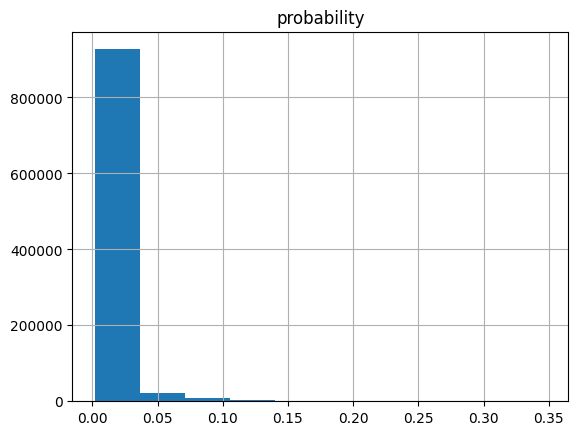

In [21]:
print(test_probs.min(), test_probs.max(), np.mean(test_probs))
pd.DataFrame(test_probs, columns=["probability"]).hist()

In [22]:
# Top 5% threshold
threshold = np.percentile(test_probs, 95)
high_risk_idx = np.where(test_probs >= threshold)[0]

test_preds = lr_model.predict(X_test)

# Get the corresponding rows in the dataset
high_risk_data = X_test.iloc[high_risk_idx]

high_risk_preds = test_preds[high_risk_idx]
high_risk_labels = y_test.iloc[high_risk_idx]
high_risk_probs = test_probs[high_risk_idx]

# high_risk_labels
# Create a DataFrame for high-risk patients
high_risk_df = pd.DataFrame(high_risk_data)

# Add the labels to the DataFrame
high_risk_df['prob'] = high_risk_probs
high_risk_df['label'] = high_risk_labels
high_risk_df['pred'] = high_risk_preds
high_risk_df

,time,alb,alp,alt,ast,be,bicar,bili,bili_dir,bnd,...,sex,height,weight,MissingIndicator_age,MissingIndicator_sex,MissingIndicator_height,MissingIndicator_weight,prob,label,pred
10,36000000,-0.497891,-0.354820,-0.231457,-0.191053,0.000000,1.083325,-0.370050,0.0,0.000000,...,1,-0.589391,0.000000,0,0,0,1,0.084039,0,0
40,54000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.640583,0.000000,0.0,0.000000,...,1,1.359796,-0.070479,0,0,0,0,0.031459,0,0
47,79200000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.446018,0.000000,0.0,-0.032362,...,1,1.359796,-0.070479,0,0,0,0,0.064091,0,0
56,10800000,-0.648949,9.168337,-0.125878,0.026793,0.000000,0.110501,-0.238974,0.0,-0.106859,...,1,-0.589391,0.000000,0,0,0,1,0.154049,0,0
66,46800000,-1.102123,7.427127,-0.148212,-0.041211,0.000000,-0.084064,-0.304512,0.0,0.712611,...,1,-0.589391,0.000000,0,0,0,1,0.137284,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959579,234000000,0.000000,0.000000,0.000000,0.000000,1.004480,1.472455,0.000000,0.0,0.000000,...,0,-1.025393,-0.487410,0,0,0,0,0.033738,0,0
959683,0,-0.044717,-0.481277,-0.249730,-0.185289,-1.179195,-0.862324,-0.402819,0.0,0.000000,...,0,-0.375664,-1.114757,0,0,0,0,0.198627,0,0
959686,10800000,-0.044717,-0.481277,-0.249730,-0.185289,-1.179195,-0.862324,-0.402819,0.0,0.000000,...,0,-0.375664,-1.114757,0,0,0,0,0.025561,0,0
959696,46800000,-0.044717,-0.481277,-0.249730,-0.185289,-0.711265,-0.862324,-0.402819,0.0,0.000000,...,0,-0.375664,-1.114757,0,0,0,0,0.092374,0,0


In [25]:
high_risk_df[high_risk_df["label"] == 1].sort_values(by="prob", ascending=False)

,time,alb,alp,alt,ast,be,bicar,bili,bili_dir,bnd,...,sex,height,weight,MissingIndicator_age,MissingIndicator_sex,MissingIndicator_height,MissingIndicator_weight,prob,label,pred
99796,21600000,-0.044717,0.919473,-0.152273,0.110935,-1.335172,-2.418843,2.153158,0.000000,0.000000,...,0,0.710067,-0.331548,0,0,0,0,0.347601,1,0
482509,25200000,-0.497891,-0.306183,-0.231457,-0.146100,-0.867242,-1.251453,0.809632,0.561541,0.000000,...,0,-1.897398,-0.836153,0,0,0,0,0.284777,1,0
655069,7200000,1.314806,0.000000,-0.058877,0.014114,-0.726863,-0.667759,-0.370050,-0.429193,0.000000,...,0,-0.375664,-0.888756,0,0,0,0,0.245344,1,0
260801,10800000,0.106341,-0.413185,-0.209123,-0.172611,-0.758058,-0.278629,-0.304512,0.000000,0.000000,...,1,0.927213,0.068239,0,0,0,0,0.211738,1,0
84275,32400000,0.559515,0.219098,1.256797,1.316579,-0.711265,-0.473194,-0.238974,0.000000,-0.702838,...,0,-0.375664,0.011349,0,0,0,0,0.208863,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71425,68400000,0.000000,0.000000,0.000000,0.000000,0.224596,0.000000,0.000000,0.000000,0.000000,...,1,0.710067,1.301110,0,0,0,0,0.024151,1,0
482507,18000000,0.710574,0.783289,-0.213184,-0.138032,-1.491149,-1.056888,0.285329,0.000000,0.000000,...,0,-1.897398,-0.836153,0,0,0,0,0.024142,1,0
645692,28800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1,-0.589391,0.182798,0,0,0,0,0.024118,1,0
346352,169200000,2.070096,-0.238091,-0.162425,-0.131116,0.380573,-0.084064,-0.140667,0.000000,0.000000,...,1,-0.161938,-0.428962,0,0,0,0,0.024036,1,0


In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
X_train.head()

X_train shape: (4501612, 106)
y_train shape: (4501612,)
shape: (5, 106)
┌─────────┬────────────┬──────────┬───────────┬───┬────────────┬───────────┬───────────┬───────────┐
│ stay_id ┆ time       ┆ alb      ┆ alp       ┆ … ┆ MissingInd ┆ MissingIn ┆ MissingIn ┆ MissingIn │
│ ---     ┆ ---        ┆ ---      ┆ ---       ┆   ┆ icator_age ┆ dicator_s ┆ dicator_h ┆ dicator_w │
│ i64     ┆ duration[m ┆ f64      ┆ f64       ┆   ┆ ---        ┆ ex        ┆ eight     ┆ eight     │
│         ┆ s]         ┆          ┆           ┆   ┆ bool       ┆ ---       ┆ ---       ┆ ---       │
│         ┆            ┆          ┆           ┆   ┆            ┆ bool      ┆ bool      ┆ bool      │
╞═════════╪════════════╪══════════╪═══════════╪═══╪════════════╪═══════════╪═══════════╪═══════════╡
│ 588427  ┆ 22h        ┆ 1.164564 ┆ -0.243995 ┆ … ┆ false      ┆ false     ┆ false     ┆ false     │
│ 1079090 ┆ 1d 9h      ┆ 0.0      ┆ 0.0       ┆ … ┆ false      ┆ false     ┆ false     ┆ false     │
│ 3002119 ┆ 5h     

In [5]:
y_test

0         0
1         0
2         0
3         0
4         0
         ..
957003    0
957004    0
957005    0
957006    0
957007    0
Name: label, Length: 957008, dtype: int8

In [ ]:
# from icu_benchmarks.data.loader import PredictionPolarsDataset

# vars = {
#     "GROUP": "stay_id",
#     "SEQUENCE": "time",
#     "LABEL": "label"
# }

# data_dict = {
#     "train": {
#         "OUTCOME": cached_data_recipe['train']['OUTCOME'],
#         "FEATURES": cached_data_recipe['train']['FEATURES']
#     },
#     "val": {
#         "OUTCOME": cached_data_recipe['val']['OUTCOME'],
#         "FEATURES": cached_data_recipe['val']['FEATURES']
#     },
#     "test": {
#         "OUTCOME": Y_test,
#         "FEATURES": X_test
#     }
# }
# dataset = PredictionPolarsDataset(data=data_dict, split = "train", vars=vars)
# feature_names = dataset.get_feature_names()
# data, labels, row_indicators = dataset.get_data_and_labels()


In [56]:
cached_data_recipe

{'train': {'OUTCOME': shape: (27_314, 3)
  ┌─────────┬──────────────┬───────┐
  │ stay_id ┆ time         ┆ label │
  │ ---     ┆ ---          ┆ ---   │
  │ i64     ┆ duration[ms] ┆ bool  │
  ╞═════════╪══════════════╪═══════╡
  │ 141765  ┆ 0ms          ┆ false │
  │ 141765  ┆ 1h           ┆ false │
  │ 141765  ┆ 2h           ┆ false │
  │ 141765  ┆ 3h           ┆ false │
  │ 141765  ┆ 4h           ┆ false │
  │ …       ┆ …            ┆ …     │
  │ 3348409 ┆ 1d 3h        ┆ false │
  │ 3348409 ┆ 1d 4h        ┆ false │
  │ 3348409 ┆ 1d 5h        ┆ false │
  │ 3348409 ┆ 1d 6h        ┆ false │
  │ 3348409 ┆ 1d 7h        ┆ false │
  └─────────┴──────────────┴───────┘,
  'FEATURES': shape: (27_314, 298)
  ┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
  │ stay_id ┆ time       ┆ alb       ┆ alp       ┆ … ┆ MissingIn ┆ MissingIn ┆ MissingIn ┆ MissingIn │
  │ ---     ┆ ---        ┆ ---       ┆ ---       ┆   ┆ dicator_a ┆ dicator_s ┆ dicator_h

In [57]:
X_test


stay_id,time,alb,alp,alt,ast,be,bicar,bili,bili_dir,bnd,bun,ca,cai,ck,ckmb,cl,crea,crp,dbp,fgn,fio2,glu,hgb,hr,inr_pt,k,lact,lymph,map,mch,mchc,mcv,methb,mg,na,neut,…,fio2___mean_hist,glu___mean_hist,hgb___mean_hist,hr___mean_hist,inr_pt___mean_hist,k___mean_hist,lact___mean_hist,lymph___mean_hist,map___mean_hist,mch___mean_hist,mchc___mean_hist,mcv___mean_hist,methb___mean_hist,mg___mean_hist,na___mean_hist,neut___mean_hist,o2sat___mean_hist,pco2___mean_hist,ph___mean_hist,phos___mean_hist,plt___mean_hist,po2___mean_hist,ptt___mean_hist,resp___mean_hist,sbp___mean_hist,temp___mean_hist,tnt___mean_hist,urine___mean_hist,wbc___mean_hist,age,sex,height,weight,MissingIndicator_age,MissingIndicator_sex,MissingIndicator_height,MissingIndicator_weight
i64,duration[ms],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,bool,bool,bool,bool
166853,5h,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.415793,0.0,0.0,1.797937,0.0,-0.986305,0.0,0.0,0.0,0.0,0.266888,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.898968,0.0,-0.995445,0.0,0.0,0.0,0.0,1.021549,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.026209,0.0,0.0,0.0,0.0,0.0,0.0,-1.001379,1.517495,-0.449908,0.0,0.232826,0.0,0.213738,1,0.343855,0.138762,false,false,false,false
827086,6h,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000601,0.0,0.0,-0.822097,0.0,1.618819,0.0,0.0,0.0,0.0,1.006752,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,-0.688871,0.0,1.728509,0.0,0.0,0.0,0.0,0.376581,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.955394,0.0,0.0,0.0,0.0,0.0,0.0,0.625687,0.662113,0.25515,0.0,0.251238,0.0,0.790267,0,-0.544119,0.0,false,false,false,true
963942,8h,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.568785,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.622089,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.052132,0.0,-0.534936,0.0,1.482102,0,-1.22109,-0.522315,false,false,false,false
733082,3d 20h,-1.824072,1.618642,-0.203534,-0.118375,0.0,-0.099439,-0.370108,0.0,0.0,-0.354708,-0.993325,0.0,0.0,0.0,1.020193,-0.490946,0.0,-0.547422,0.0,-0.616451,1.053977,-1.482242,1.591397,-0.400056,0.182098,0.080259,0.0,-0.620948,0.199023,0.99188,-0.237245,0.0,-1.366746,0.195012,0.0,…,-0.616451,0.318885,-0.786717,1.392069,-0.369944,-0.163818,0.066464,0.0,-0.348869,0.075562,1.037048,-0.410445,0.0,-0.123005,-0.363876,0.0,0.3106,0.0,0.0,-0.390412,1.03215,0.0,-0.507522,-0.461626,-0.036522,-0.172393,0.0,0.960535,8.682287,0.213738,0,-1.22109,-0.41526,false,false,false,false
1856168,6d 13h,0.346714,-1.035823,-0.233041,-0.153409,0.397996,0.45479,-0.147325,0.0,0.0,-0.777823,1.02802,0.0,-0.608754,0.0,-1.081889,-0.449113,0.0,1.654211,0.0,-0.197245,-0.450117,1.363803,-0.766926,-0.400056,-0.508304,-0.604748,0.4925,1.243508,-0.080111,-0.810801,0.350137,0.0,-0.785372,-0.52801,-0.939504,…,-0.176399,-0.916698,1.825939,-1.042191,-0.058236,-0.310267,-0.367442,1.322614,0.743023,0.022638,-0.746683,0.433786,0.0,0.005126,-0.78692,-1.402802,0.15394,-0.035991,0.373456,0.293023,0.087466,-0.470388,-0.118649,-1.058618,-0.031108,-0.134491,0.0,2.920579,-0.526067,-0.53575,1,-0.104528,1.117673,false,false,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
631264,1d,0.0,0.0,0.0,0.0,0.0,-0.284182,0.0,0.0,0.0,0.249742,0.775351,0.0,0.0,0.0,-0.331146,-0.100508,0.0,-0.478621,0.0,0.0,-0.563328,1.970338,-0.547547,0.0,-1.198705,0.0,0.0,-0.739326,1.036424,0.74606,0.790673,0.0,0.0,-0.347254,0.0,…,0.0,-0.112666,0.394068,-0.651788,0.0,-0.239741,0.0,0.0,-0.637564,0.207285,0.149212,0.158135,0.0,0.0,-0.069451,0.0,-0.216951,0.0,0.0,0.0,-0.058887,0.0,0.0,0.639977,-0.249041,0.143274,0.0,0.0,0.061336,1.482102,0,-1.300217,-0.852646,f